In [14]:
import gpflow as gpf 
import numpy as np
import scipy.stats as ss
import tensorflow as tf 
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm
import os

import sys
sys.path.append("../..")

from atmodel import AdaptiveTransferGPR, ConditionalMOGP, SparseCMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

In [15]:
def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50, "maxiter": 250})
    plt.plot(res["loss_history"])
    plt.show()

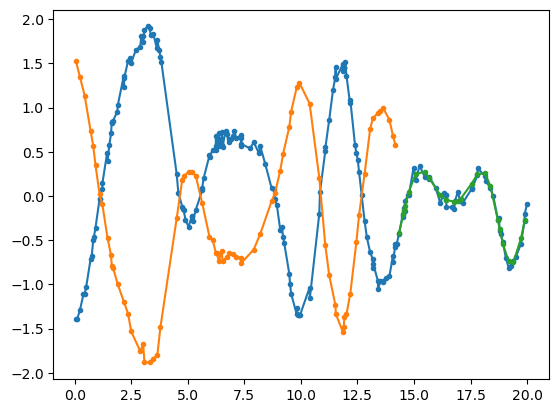

In [16]:
k = gpf.kernels.RBF(lengthscales=1, variance=1) #+ gpf.kernels.Linear(0.001)
Xall = np.sort(np.random.random(200) * 20)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall), k(Xall.reshape(-1, 1)))
ind_1 = np.arange(0, 200, 1)
ind_2 = np.array([i for i in ind_1 if i % 2 == 0])
ind_1 = ind_1
ind_2 = ind_2
TEST_INDEX = int(0.75*len(ind_2))
ind_train, ind_test = ind_2[:TEST_INDEX], ind_2[TEST_INDEX:]
X1, y1 = Xall[ind_1], Yall[ind_1]
X2, y2 = Xall[ind_train], Yall[ind_train]
X2 = X2
y2 = -1*y2
Xtest, ytest = Xall[ind_test], Yall[ind_test]

y1 = y1.reshape(-1, 1) + np.random.normal(0, 0.05, len(X1)).reshape(-1, 1)
y2 = y2.reshape(-1, 1) + np.random.normal(0, 0.05, len(X2)).reshape(-1, 1) 
X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)
plt.plot(X1, y1, marker=".")
plt.plot(X2, y2, marker=".")
plt.plot(Xtest, ytest, marker=".")
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
plt.show()
X = tf.cast(X, np.float64)
y = tf.cast(y, np.float64)

In [17]:
exponents = np.arange(2, 13)
superlmls = []
output_dim = 2  # Number of outputs
rank = 1  # Rank of W
cross_cov = np.arange(-1, 1.25, 0.25)
for i in cross_cov:
    lmls = []
    for exponent in exponents:
        print(2 ** exponent)
        k = gpf.kernels.RBF(lengthscales=1)
        coreg = gpf.kernels.Coregion(
            output_dim=output_dim, rank=rank, active_dims=[1]
        )
        coreg.W = np.array([1., i]).reshape(-1, 1)
        kern = k * coreg
        m2 = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
        k = gpf.kernels.RBF(lengthscales=1)

        # Base kernel
        coreg = gpf.kernels.Coregion(
            output_dim=output_dim, rank=rank, active_dims=[1]
        )
        coreg.W = np.array([1., i]).reshape(-1, 1)

        # Coregion kernel
        ivs = np.linspace(0, max(X[:,0]), 2 ** exponent).reshape(-1, 1)
        iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
        shuffle = np.random.permutation(np.arange(len(ivs)))
        iv_ind = iv_ind[shuffle]
        ivs = np.hstack((ivs, iv_ind))
        kern = k * coreg
        m = SparseCMOGP((X, y), exact_target=False, kernel=kern, inducing_variable=ivs, jitter=1e-5, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
        lmls.append((m.maximum_log_likelihood_objective(), m2.maximum_log_likelihood_objective()))
    print(lmls)
    superlmls.append(lmls)
lmls = np.array(superlmls)



4
TensorShape([200, 200])
TensorShape([200, 200])
8
TensorShape([200, 200])
TensorShape([200, 200])
16
TensorShape([200, 200])
TensorShape([200, 200])
32
TensorShape([200, 200])
TensorShape([200, 200])
64
TensorShape([200, 200])
TensorShape([200, 200])
128
TensorShape([200, 200])
TensorShape([200, 200])
256
TensorShape([200, 200])
TensorShape([200, 200])
512
TensorShape([200, 200])
TensorShape([200, 200])
1024
TensorShape([200, 200])
TensorShape([200, 200])
2048
TensorShape([200, 200])
TensorShape([200, 200])
4096
TensorShape([200, 200])
TensorShape([200, 200])
[(<tf.Tensor: shape=(), dtype=float64, numpy=-117.60225544443576>, <tf.Tensor: shape=(), dtype=float64, numpy=-86.64004812429133>), (<tf.Tensor: shape=(), dtype=float64, numpy=-108.9758326794814>, <tf.Tensor: shape=(), dtype=float64, numpy=-86.64004812429133>), (<tf.Tensor: shape=(), dtype=float64, numpy=-96.68680738106275>, <tf.Tensor: shape=(), dtype=float64, numpy=-86.64004812429133>), (<tf.Tensor: shape=(), dtype=float64, nu

(11, 2)


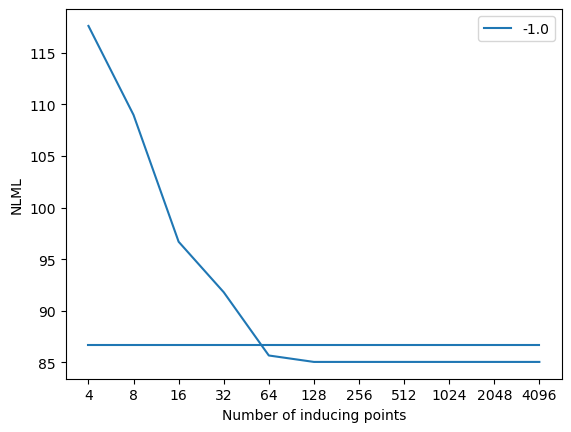

(11, 2)


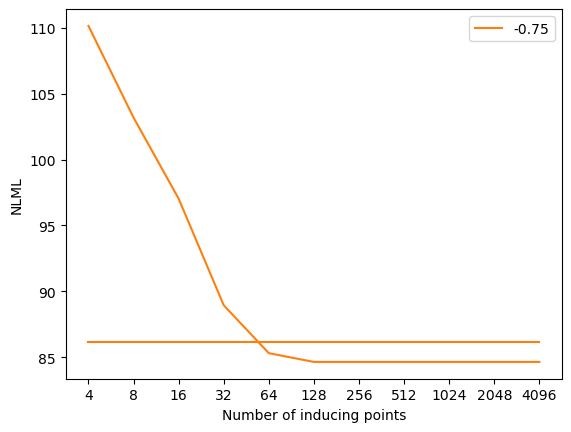

(11, 2)


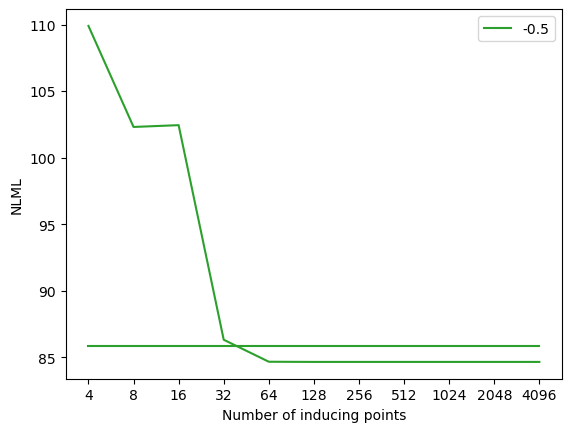

(11, 2)


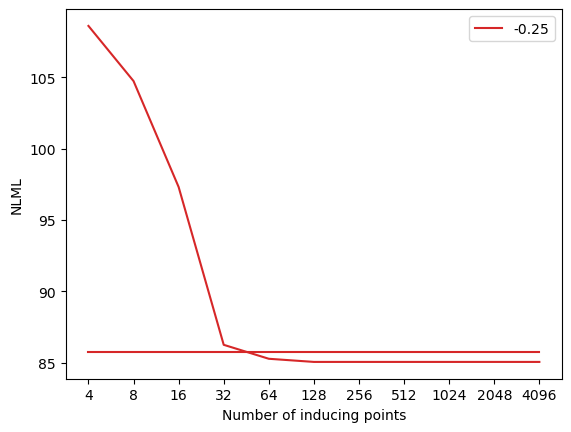

(11, 2)


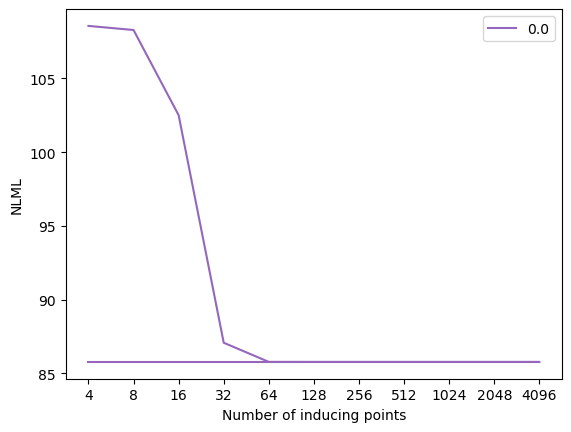

(11, 2)


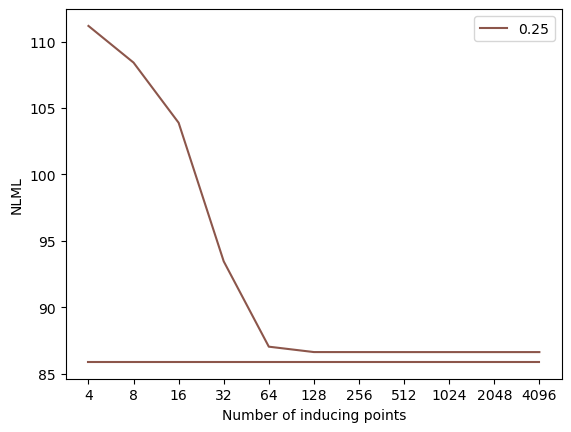

(11, 2)


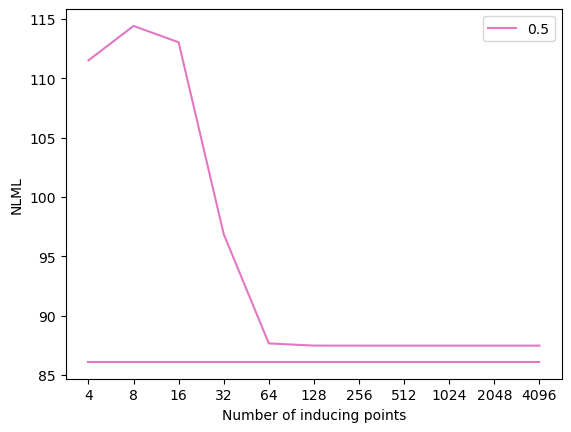

(11, 2)


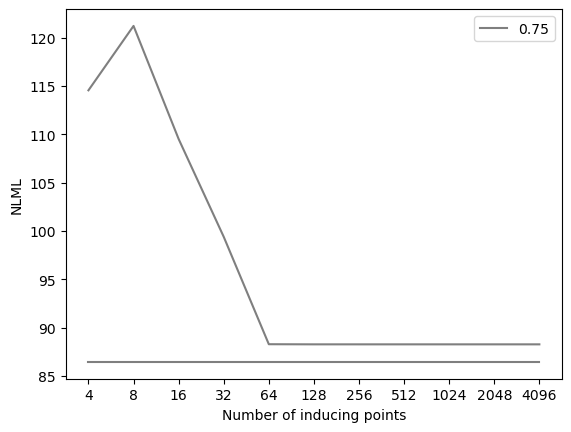

(11, 2)


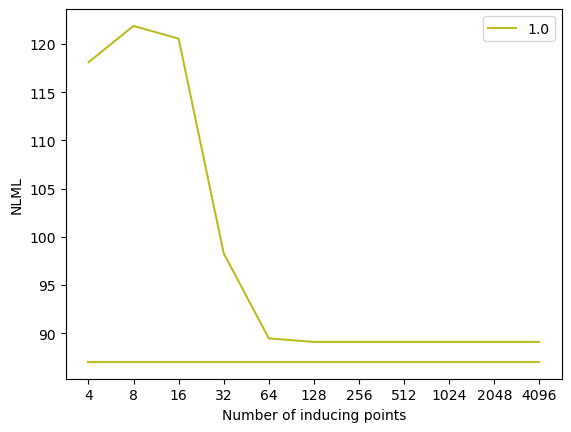

In [18]:
import matplotlib.colors as mcolors
colorlist = list(mcolors.TABLEAU_COLORS.values())
for j, l in enumerate(lmls):
    print(l.shape)
    plt.plot(exponents, -l[:,0], color=colorlist[j], label=cross_cov[j])
    plt.plot(exponents, -l[:,1], color=colorlist[j])
    plt.xticks(exponents, 2 ** exponents)
    plt.xlabel("Number of inducing points")
    plt.ylabel("NLML")
    plt.legend()
    plt.show()

In [22]:
exponents = np.arange(2, 13)
superlmls = []
output_dim = 2  # Number of outputs
rank = 1  # Rank of W
cross_cov = np.arange(-1, 1.25, 0.25)
for i in cross_cov:
    lmls = []
    for exponent in exponents:
        print(2 ** exponent)
        k = gpf.kernels.RBF(lengthscales=1)
        coreg = gpf.kernels.Coregion(
            output_dim=output_dim, rank=rank, active_dims=[1]
        )
        coreg.W = np.array([1., i]).reshape(-1, 1)
        kern = k * coreg
        m2 = gpf.models.VGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
        k = gpf.kernels.RBF(lengthscales=1)

        # Base kernel
        coreg = gpf.kernels.Coregion(
            output_dim=output_dim, rank=rank, active_dims=[1]
        )
        coreg.W = np.array([1., i]).reshape(-1, 1)

        # Coregion kernel
        ivs = np.linspace(0, max(X[:,0]), 2 ** exponent).reshape(-1, 1)
        iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
        shuffle = np.random.permutation(np.arange(len(ivs)))
        iv_ind = iv_ind[shuffle]
        ivs = np.hstack((ivs, iv_ind))
        kern = k * coreg
        m = gpf.models.SVGP(kernel=kern, inducing_variable=ivs, num_data=len(X), likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
        lmls.append((m.training_loss_closure((X, y))(), m2.maximum_log_likelihood_objective()))
    print(lmls)
    superlmls.append(lmls)
lmls = np.array(superlmls)


4
8
16
32
64
128
256
512
1024
2048
4096
[(<tf.Tensor: shape=(), dtype=float64, numpy=635.311742073411>, <tf.Tensor: shape=(), dtype=float64, numpy=-1270.8984841468218>), (<tf.Tensor: shape=(), dtype=float64, numpy=635.311742073411>, <tf.Tensor: shape=(), dtype=float64, numpy=-1270.8984841468218>), (<tf.Tensor: shape=(), dtype=float64, numpy=635.311742073411>, <tf.Tensor: shape=(), dtype=float64, numpy=-1270.8984841468218>), (<tf.Tensor: shape=(), dtype=float64, numpy=635.311742073411>, <tf.Tensor: shape=(), dtype=float64, numpy=-1270.8984841468218>), (<tf.Tensor: shape=(), dtype=float64, numpy=635.311742073411>, <tf.Tensor: shape=(), dtype=float64, numpy=-1270.8984841468218>), (<tf.Tensor: shape=(), dtype=float64, numpy=635.311742073411>, <tf.Tensor: shape=(), dtype=float64, numpy=-1270.8984841468218>), (<tf.Tensor: shape=(), dtype=float64, numpy=635.311742073411>, <tf.Tensor: shape=(), dtype=float64, numpy=-1270.8984841468218>), (<tf.Tensor: shape=(), dtype=float64, numpy=635.31174207

(11, 2)


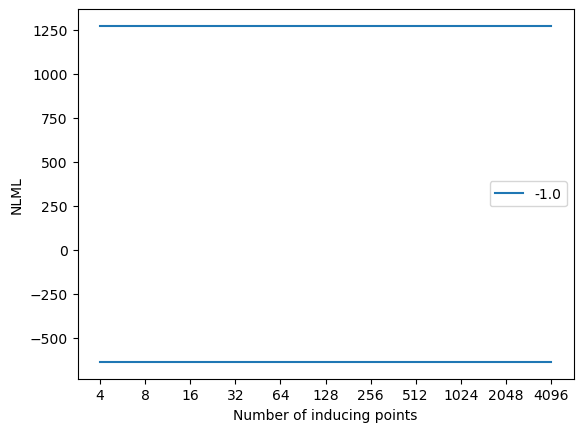

(11, 2)


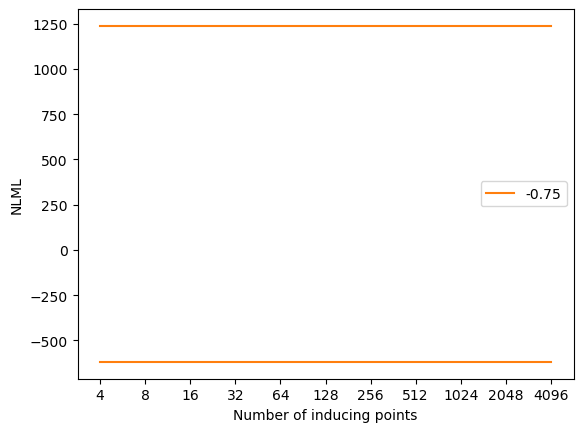

(11, 2)


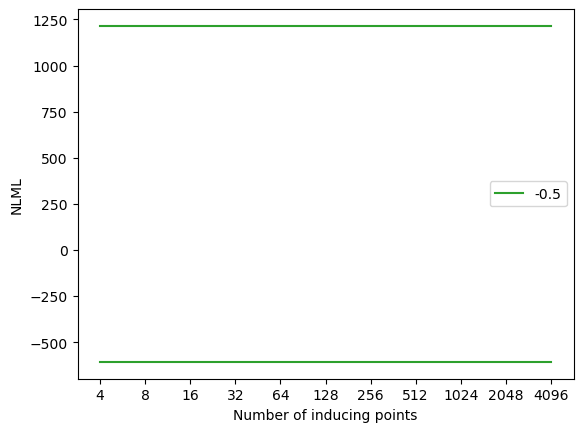

(11, 2)


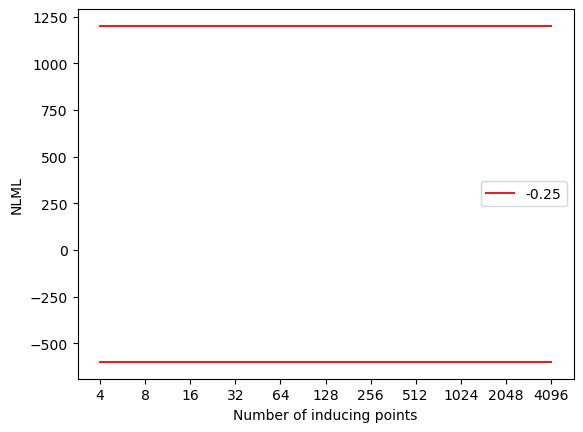

(11, 2)


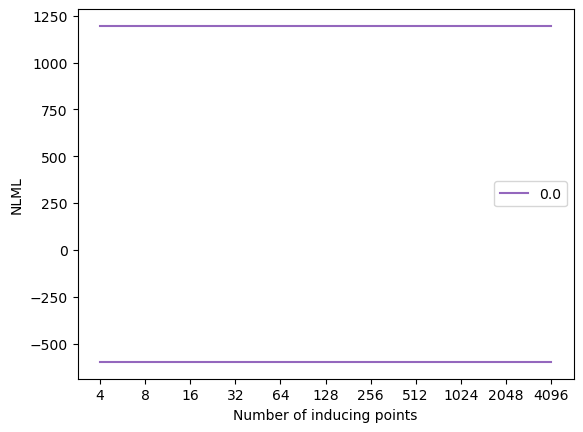

(11, 2)


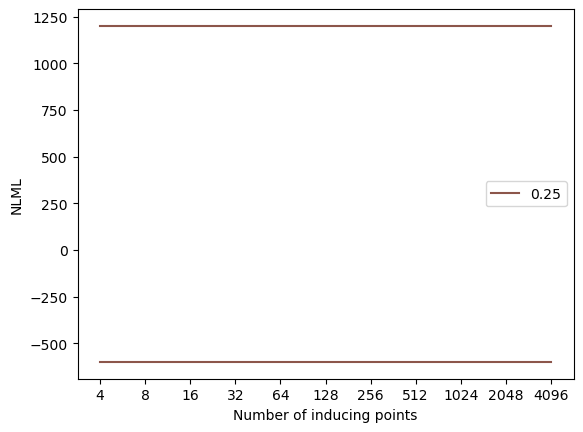

(11, 2)


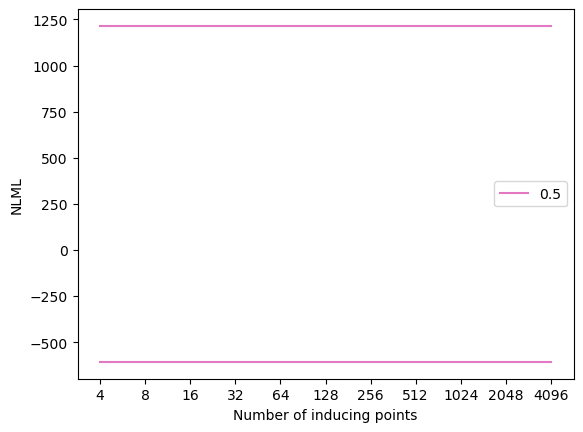

(11, 2)


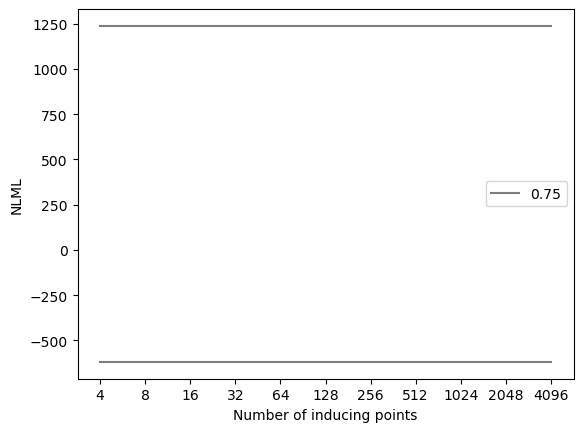

(11, 2)


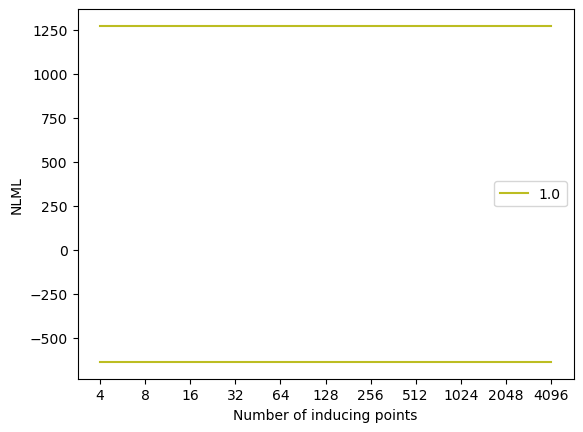

In [24]:
import matplotlib.colors as mcolors
colorlist = list(mcolors.TABLEAU_COLORS.values())
for j, l in enumerate(lmls):
    print(l.shape)
    plt.plot(exponents, -l[:,0], color=colorlist[j], label=cross_cov[j])
    plt.plot(exponents, -l[:,1], color=colorlist[j])
    plt.xticks(exponents, 2 ** exponents)
    plt.xlabel("Number of inducing points")
    plt.ylabel("NLML")
    plt.legend()
    plt.show()